<a href="https://colab.research.google.com/github/packageIncoming/MAT422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

**Topics:** singular value decomposition, low-rank matrix approximations, principal component analysis

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Singular value decomposition factors a matrix A into A = U Sigma V^T. The columns of U and V are orthonormal directions, and the singular values in Sigma measure how much each direction contributes to the matrix.

Informally it represents applying rotation(V)->stretch(D or Sigma)->second rotation(U).


In [6]:
A = np.array([
    [6, 7, 4],
    [2, 8, -4],
    [1, 4, 7],
    [2, 3, 9],
], dtype=float)

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
A_reconstructed = U @ Sigma @ Vt

print("A =")
print(A)
print("\nSingular values =", s)
print("\nU shape, Sigma shape, Vt shape =", U.shape, Sigma.shape, Vt.shape)
print("\nU.T @ U =")
print(U.T @ U)
print("\nVt @ Vt.T =")
print(Vt @ Vt.T)
print("\nReconstruction error ||A - U Sigma Vt||_F =", np.linalg.norm(A - A_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(A, A_reconstructed))

A =
[[ 6.  7.  4.]
 [ 2.  8. -4.]
 [ 1.  4.  7.]
 [ 2.  3.  9.]]

Singular values = [15.2568 10.2133  2.8141]

U shape, Sigma shape, Vt shape = (4, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Vt @ Vt.T =
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Reconstruction error ||A - U Sigma Vt||_F = 9.283482853724433e-15
Reconstruction is accurate? True


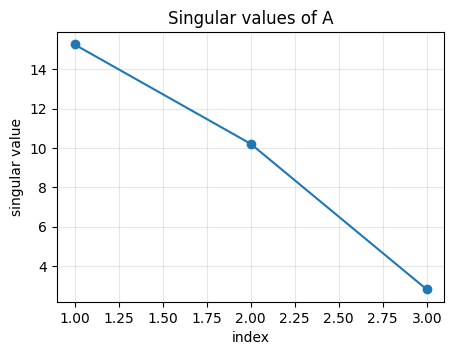

In [7]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of A")
plt.grid(True, alpha=0.3)
plt.show()

Large singular values indicate directions that carry more structure. Smaller singular values contribute less, which is why SVD is useful for approximation and compression.

## 1.4.2 Low-Rank Matrix Approximations

A rank-k approximation keeps only the first k singular values and singular vectors. This gives a simpler matrix A_k that captures the strongest patterns in A.

In [8]:
def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

errors = []
for k in range(1, len(s) + 1):
    A_k = rank_k_approximation(U, s, Vt, k)
    error = np.linalg.norm(A - A_k, ord="fro")
    errors.append(error)
    print(f"Rank-{k} approximation:")
    print(A_k)
    print("Frobenius error =", error)
    print("matrix rank =", np.linalg.matrix_rank(A_k))
    print()

Rank-1 approximation:
[[3.5443 5.9594 6.348 ]
 [1.178  1.9806 2.1098]
 [2.8803 4.843  5.1588]
 [3.2926 5.5362 5.8973]]
Frobenius error = 10.593923184515095
matrix rank = 1

Rank-2 approximation:
[[ 4.2244  7.8538  4.1899]
 [ 3.1418  7.451  -4.1221]
 [ 2.3455  3.3531  6.8561]
 [ 2.3259  2.8433  8.9651]]
Frobenius error = 2.814124974858607
matrix rank = 2

Rank-3 approximation:
[[ 6.  7.  4.]
 [ 2.  8. -4.]
 [ 1.  4.  7.]
 [ 2.  3.  9.]]
Frobenius error = 9.283482853724433e-15
matrix rank = 3



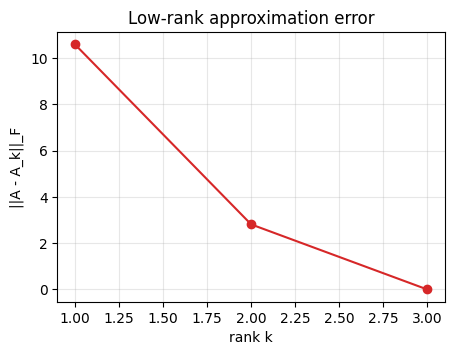

In [9]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors) + 1), errors, marker="o", color="tab:red")
plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

The approximation error decreases as k increases. When k reaches the full rank, the approximation becomes the original matrix up to numerical roundoff.

Also to note: informally, the Frobenius error is simple linear difference between two matrices.

## 1.4.3 Principal Component Analysis

Principal component analysis finds directions of maximum variation in centered data. PCA can be computed using SVD: after centering the data matrix X, the rows of V^T give principal component directions.

In [10]:
X = np.array([
    [3.5, 2.4],
    [1.5, 0.7],
    [3.2, 2.9],
    [2.9, 2.2],
    [4.1, 3.0],
    [3.3, 2.7],
    [3.0, 1.6],
    [2.0, 1.1],
    [2.5, 1.6],
    [2.1, 0.9],
], dtype=float)

mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ Vt_pca.T
explained_variance = (s_pca**2) / (len(X) - 1)
explained_ratio = explained_variance / explained_variance.sum()

print("feature means =", mean)
print("principal directions as rows of Vt =")
print(Vt_pca)
print("singular values =", s_pca)
print("explained variance =", explained_variance)
print("explained variance ratio =", explained_ratio)
print("first three PCA scores =")
print(scores[:3])

feature means = [2.81 1.91]
principal directions as rows of Vt =
[[-0.6779 -0.7352]
 [ 0.7352 -0.6779]]
singular values = [3.3994 0.6646]
explained variance = [1.284  0.0491]
explained variance ratio = [0.9632 0.0368]
first three PCA scores =
[[-0.828   0.1751]
 [ 1.7776 -0.1429]
 [-0.9922 -0.3844]]


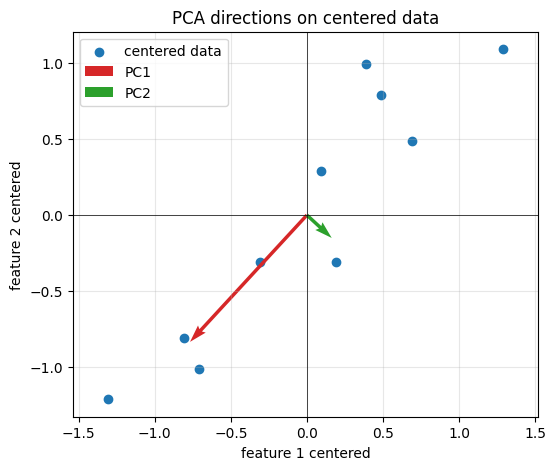

In [11]:
origin = np.zeros(2)
pc1 = Vt_pca[0] * s_pca[0] / np.sqrt(len(X) - 1)
pc2 = Vt_pca[1] * s_pca[1] / np.sqrt(len(X) - 1)

plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")
plt.quiver(*origin, *pc1, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*origin, *pc2, angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

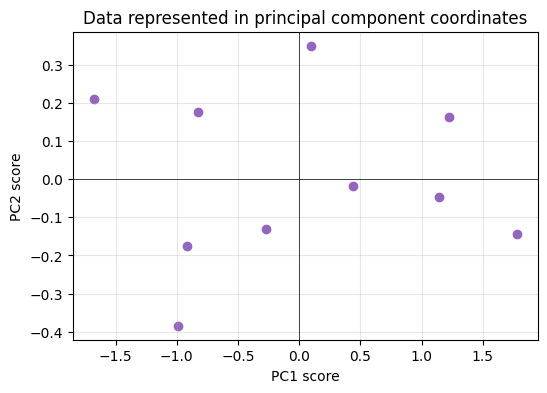

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(scores[:, 0], scores[:, 1], color="tab:purple")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data represented in principal component coordinates")
plt.grid(True, alpha=0.3)
plt.show()

The first principal component explains the largest share of variance. Projecting data onto PC1 and PC2 rotates the coordinate system so the strongest variation appears along the first axis.

## Reflection and Rubric Checklist

- [X] Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- [X] Math Concept Coverage: I demonstrated SVD, low-rank approximation, and PCA.
- [X] Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- [X] Explanation and Documentation: I explained the purpose and meaning of each code section.
- [X] GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- [X] Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- [X] Personalization: I changed or extended at least one example so the notebook reflects my own work.